In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned_supply_chain.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset loaded successfully!
Rows: 1000
Columns: 15


,Order_ID,Order_Date,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Quantity,Unit_Price,Sales,Stock,Reorder_Level,Delivery_Days,Delivery_Status,Order_Status
0,1001,2025-02-04,P006,Mouse,Accessories,S004,Prime Distributors,18,800,14400,80,26,2,On Time,Delivered
1,1002,2025-12-10,P009,Office Chair,Furniture,S004,Prime Distributors,13,7000,91000,61,20,10,On Time,Delivered
2,1003,2025-09-09,P004,Monitor,Electronics,S005,Reliable Suppliers,9,12000,108000,54,23,5,On Time,Delivered
3,1004,2025-03-09,P009,Office Chair,Furniture,S002,Global Electronics,5,7000,35000,48,20,4,Delayed,Delivered
4,1005,2025-12-26,P008,Printer,Office,S004,Prime Distributors,18,15000,270000,68,27,7,Delayed,Delivered


In [2]:
suppliers = df["Supplier_Name"].unique()

print("Suppliers:")
for supplier in suppliers:
    print(supplier)

Suppliers:
Prime Distributors
Reliable Suppliers
Global Electronics
Tech Supplier Ltd
Smart Supply Co


In [3]:
supplier_orders = (
    df.groupby("Supplier_Name")["Order_ID"]
    .count()
    .sort_values(ascending=False)
)

print("Supplier-wise Total Orders:")
print(supplier_orders)

Supplier-wise Total Orders:
Supplier_Name
Reliable Suppliers    215
Smart Supply Co       204
Tech Supplier Ltd     199
Global Electronics    195
Prime Distributors    187
Name: Order_ID, dtype: int64


In [4]:
supplier_sales = (
    df.groupby("Supplier_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Supplier-wise Sales:")
print(supplier_sales)

Supplier-wise Sales:
Supplier_Name
Smart Supply Co       34540700
Reliable Suppliers    32570400
Tech Supplier Ltd     28681800
Prime Distributors    28435500
Global Electronics    26115600
Name: Sales, dtype: int64


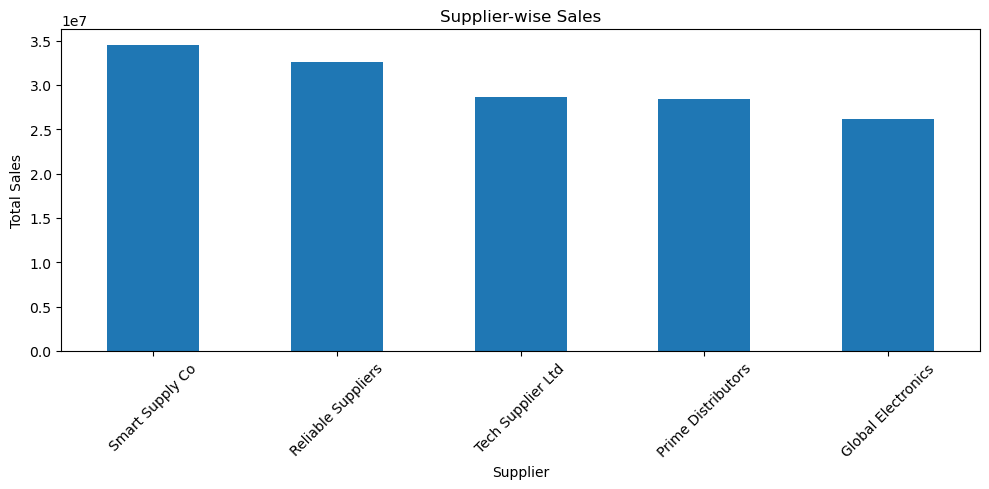

In [5]:
plt.figure(figsize=(10, 5))

supplier_sales.plot(kind="bar")

plt.title("Supplier-wise Sales")
plt.xlabel("Supplier")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [6]:
average_delivery = (
    df.groupby("Supplier_Name")["Delivery_Days"]
    .mean()
    .sort_values()
)

print("Average Delivery Days:")
print(average_delivery)

Average Delivery Days:
Supplier_Name
Reliable Suppliers    6.809302
Prime Distributors    7.064171
Smart Supply Co       7.191176
Tech Supplier Ltd     7.311558
Global Electronics    7.374359
Name: Delivery_Days, dtype: float64


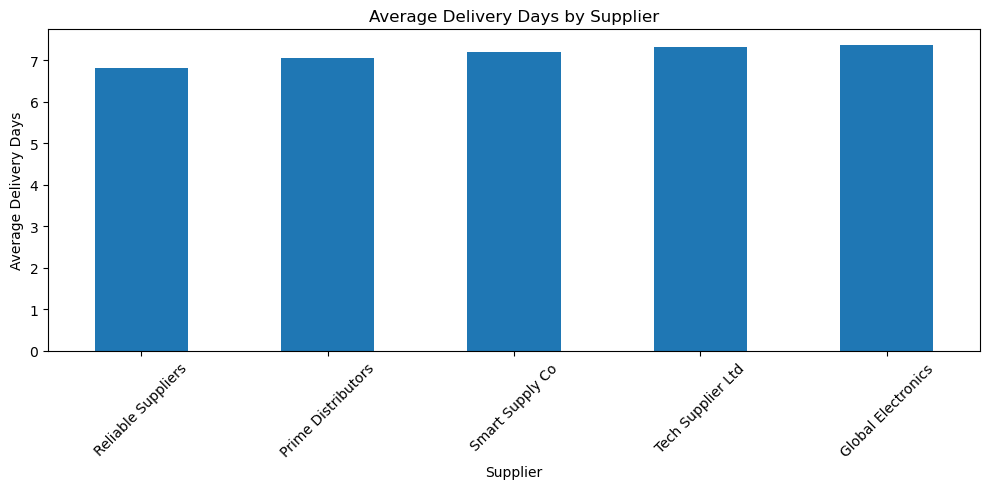

In [7]:
plt.figure(figsize=(10, 5))

average_delivery.plot(kind="bar")

plt.title("Average Delivery Days by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Average Delivery Days")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [8]:
#Delayed Orders by Supplier


In [9]:
delayed_orders = df[df["Delivery_Status"] == "Delayed"]

delayed_by_supplier = (
    delayed_orders.groupby("Supplier_Name")["Order_ID"]
    .count()
    .sort_values(ascending=False)
)

print("Delayed Orders by Supplier:")
print(delayed_by_supplier)

Delayed Orders by Supplier:
Supplier_Name
Tech Supplier Ltd     88
Smart Supply Co       87
Reliable Suppliers    83
Global Electronics    78
Prime Distributors    78
Name: Order_ID, dtype: int64


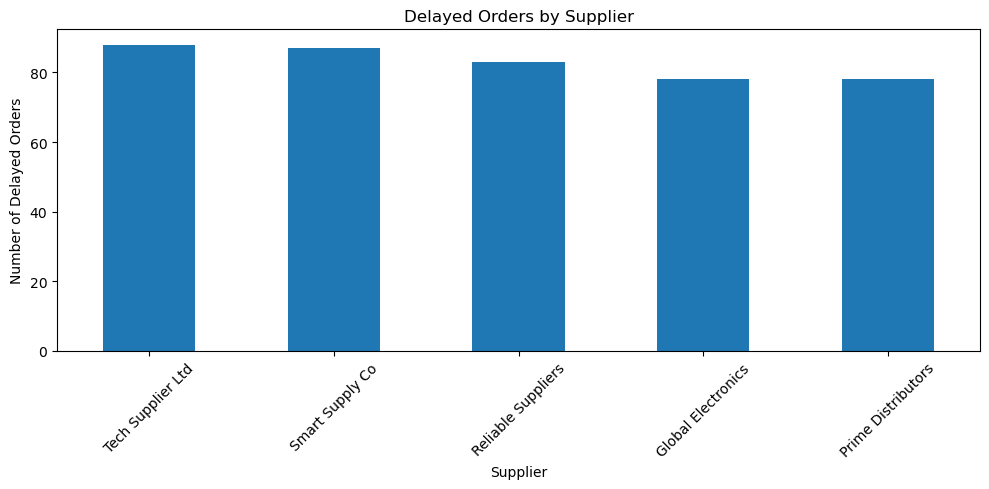

In [10]:
plt.figure(figsize=(10, 5))

delayed_by_supplier.plot(kind="bar")

plt.title("Delayed Orders by Supplier")
plt.xlabel("Supplier")
plt.ylabel("Number of Delayed Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
#On-Time Delivery Rate ⭐

In [12]:
supplier_performance = (
    df.groupby("Supplier_Name")
    .agg(
        Total_Orders=("Order_ID", "count"),
        On_Time_Orders=("Delivery_Status", lambda x: (x == "On Time").sum()),
        Delayed_Orders=("Delivery_Status", lambda x: (x == "Delayed").sum()),
        Average_Delivery_Days=("Delivery_Days", "mean"),
        Total_Sales=("Sales", "sum")
    )
)

supplier_performance["On_Time_Rate"] = (
    supplier_performance["On_Time_Orders"]
    / supplier_performance["Total_Orders"]
    * 100
)

supplier_performance

,Total_Orders,On_Time_Orders,Delayed_Orders,Average_Delivery_Days,Total_Sales,On_Time_Rate
Supplier_Name,,,,,,
Global Electronics,195,117,78,7.374359,26115600,60.000000
Prime Distributors,187,109,78,7.064171,28435500,58.288770
Reliable Suppliers,215,132,83,6.809302,32570400,61.395349
Smart Supply Co,204,117,87,7.191176,34540700,57.352941
Tech Supplier Ltd,199,111,88,7.311558,28681800,55.778894


In [13]:
supplier_performance["Average_Delivery_Days"] = (
    supplier_performance["Average_Delivery_Days"].round(2)
)

supplier_performance["On_Time_Rate"] = (
    supplier_performance["On_Time_Rate"].round(2)
)

supplier_performance

,Total_Orders,On_Time_Orders,Delayed_Orders,Average_Delivery_Days,Total_Sales,On_Time_Rate
Supplier_Name,,,,,,
Global Electronics,195,117,78,7.37,26115600,60.00
Prime Distributors,187,109,78,7.06,28435500,58.29
Reliable Suppliers,215,132,83,6.81,32570400,61.40
Smart Supply Co,204,117,87,7.19,34540700,57.35
Tech Supplier Ltd,199,111,88,7.31,28681800,55.78


In [14]:
#On-Time Delivery Rate Chart

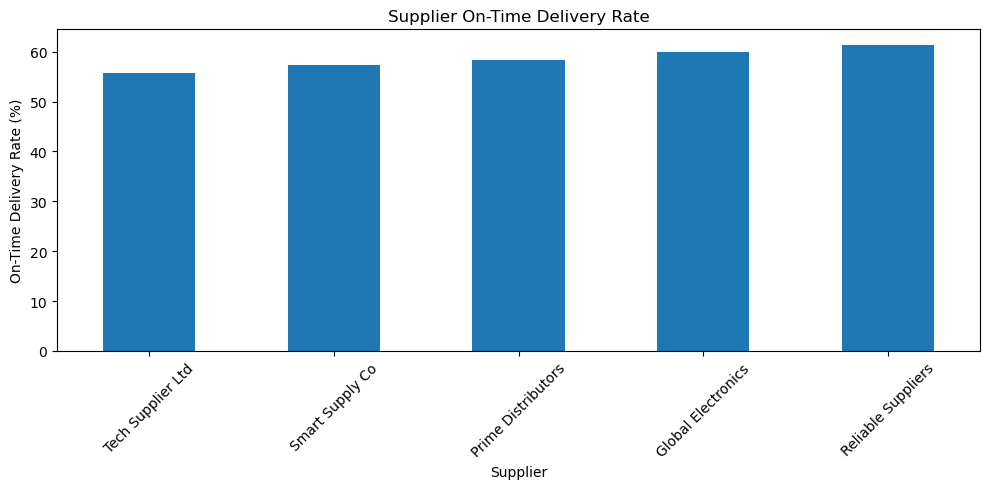

In [15]:
plt.figure(figsize=(10, 5))

supplier_performance["On_Time_Rate"].sort_values().plot(kind="bar")

plt.title("Supplier On-Time Delivery Rate")
plt.xlabel("Supplier")
plt.ylabel("On-Time Delivery Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
print("========== SUPPLIER PERFORMANCE ==========")

print(
    supplier_performance[
        [
            "Total_Orders",
            "Total_Sales",
            "Average_Delivery_Days",
            "Delayed_Orders",
            "On_Time_Rate"
        ]
    ]
)

print("==========================================")

========== SUPPLIER PERFORMANCE ==========
                    Total_Orders  Total_Sales  Average_Delivery_Days  \
Supplier_Name                                                          
Global Electronics           195     26115600                   7.37   
Prime Distributors           187     28435500                   7.06   
Reliable Suppliers           215     32570400                   6.81   
Smart Supply Co              204     34540700                   7.19   
Tech Supplier Ltd            199     28681800                   7.31   

                    Delayed_Orders  On_Time_Rate  
Supplier_Name                                     
Global Electronics              78         60.00  
Prime Distributors              78         58.29  
Reliable Suppliers              83         61.40  
Smart Supply Co                 87         57.35  
Tech Supplier Ltd               88         55.78  


In [17]:
supplier_performance.to_csv(
    "../data/supplier_analysis.csv"
)

print("Supplier analysis saved successfully!")

Supplier analysis saved successfully!
